In [1]:
import os
import sys
import json
import joblib

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
sys.path.insert(
    0,
    r"C:\Users\MALAY\sentinel\ai\app"
)

from src.data_loader import load_phishing_dataset

print("Dataset loader imported successfully")

Dataset loader imported successfully


In [3]:
df = load_phishing_dataset()

print("Dataset shape:", df.shape)

print("\nColumns:")
print(list(df.columns))

print("\nFirst 5 rows:")
display(df.head())

Loading dataset from:
C:\Users\MALAY\sentinel\ai\datasets\phiusiil.csv
Dataset loaded successfully.
Shape: (235795, 56)
Dataset shape: (235795, 56)

Columns:
['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'No

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [4]:
from services.url_feature_extractor import extract_url_features

print("URL feature extractor imported successfully")

URL feature extractor imported successfully


In [5]:
test_url = "https://www.google.com"

test_features = extract_url_features(
    test_url
)

print("Number of features:", len(test_features))

print("\nExtracted features:\n")

for feature, value in test_features.items():

    print(
        f"{feature:35} : {value}"
    )

Number of features: 22

Extracted features:

URLLength                           : 22
DomainLength                        : 14
IsDomainIP                          : 0
NoOfSubDomain                       : 1
NoOfLettersInURL                    : 17
NoOfDigitsInURL                     : 0
NoOfEqualsInURL                     : 0
NoOfQMarkInURL                      : 0
NoOfAmpersandInURL                  : 0
NoOfOtherSpecialCharsInURL          : 1
NoOfLettersInDomain                 : 12
NoOfDigitsInDomain                  : 0
PathLength                          : 0
IsHTTPS                             : 1
HasPort                             : 0
IsShortenedURL                      : 0
SuspiciousWordCount                 : 0
HasAtSymbol                         : 0
HyphenCount                         : 0
DotCount                            : 2
QueryLength                         : 0
FragmentLength                      : 0


In [6]:
print("Available columns:\n")

for i, column in enumerate(df.columns):

    print(
        i,
        "->",
        column
    )

Available columns:

0 -> FILENAME
1 -> URL
2 -> URLLength
3 -> Domain
4 -> DomainLength
5 -> IsDomainIP
6 -> TLD
7 -> URLSimilarityIndex
8 -> CharContinuationRate
9 -> TLDLegitimateProb
10 -> URLCharProb
11 -> TLDLength
12 -> NoOfSubDomain
13 -> HasObfuscation
14 -> NoOfObfuscatedChar
15 -> ObfuscationRatio
16 -> NoOfLettersInURL
17 -> LetterRatioInURL
18 -> NoOfDegitsInURL
19 -> DegitRatioInURL
20 -> NoOfEqualsInURL
21 -> NoOfQMarkInURL
22 -> NoOfAmpersandInURL
23 -> NoOfOtherSpecialCharsInURL
24 -> SpacialCharRatioInURL
25 -> IsHTTPS
26 -> LineOfCode
27 -> LargestLineLength
28 -> HasTitle
29 -> Title
30 -> DomainTitleMatchScore
31 -> URLTitleMatchScore
32 -> HasFavicon
33 -> Robots
34 -> IsResponsive
35 -> NoOfURLRedirect
36 -> NoOfSelfRedirect
37 -> HasDescription
38 -> NoOfPopup
39 -> NoOfiFrame
40 -> HasExternalFormSubmit
41 -> HasSocialNet
42 -> HasSubmitButton
43 -> HasHiddenFields
44 -> HasPasswordField
45 -> Bank
46 -> Pay
47 -> Crypto
48 -> HasCopyrightInfo
49 -> NoOfImage
50

In [7]:
URL_COLUMN = "URL"

LABEL_COLUMN = "label"

print("URL column:", URL_COLUMN)

print("Label column:", LABEL_COLUMN)

URL column: URL
Label column: label


In [8]:
print(
    df[LABEL_COLUMN].value_counts()
)

print(
    "\nUnique labels:"
)

print(
    df[LABEL_COLUMN].unique()
)

label
1    134850
0    100945
Name: count, dtype: int64

Unique labels:
[1 0]


In [9]:
feature_rows = []

valid_indices = []

print(
    "Starting URL feature extraction..."
)

for index, url in enumerate(
    df[URL_COLUMN]
):

    try:

        features = extract_url_features(
            str(url)
        )

        feature_rows.append(
            features
        )

        valid_indices.append(
            index
        )

    except Exception as error:

        print(
            f"Skipping row {index}: {error}"
        )

print(
    "\nFeature extraction completed."
)

print(
    "Valid rows:",
    len(feature_rows)
)

Starting URL feature extraction...

Feature extraction completed.
Valid rows: 235795


In [10]:
X = pd.DataFrame(
    feature_rows
)

print(
    "X shape:",
    X.shape
)

print(
    "\nFeature count:",
    len(X.columns)
)

print(
    "\nFeatures:"
)

for feature in X.columns:

    print(
        " -",
        feature
    )

X shape: (235795, 22)

Feature count: 22

Features:
 - URLLength
 - DomainLength
 - IsDomainIP
 - NoOfSubDomain
 - NoOfLettersInURL
 - NoOfDigitsInURL
 - NoOfEqualsInURL
 - NoOfQMarkInURL
 - NoOfAmpersandInURL
 - NoOfOtherSpecialCharsInURL
 - NoOfLettersInDomain
 - NoOfDigitsInDomain
 - PathLength
 - IsHTTPS
 - HasPort
 - IsShortenedURL
 - SuspiciousWordCount
 - HasAtSymbol
 - HyphenCount
 - DotCount
 - QueryLength
 - FragmentLength


In [11]:
y = (
    df.loc[
        valid_indices,
        LABEL_COLUMN
    ]
    .reset_index(
        drop=True
    )
)

print(
    "y shape:",
    y.shape
)

print(
    "\nLabel distribution:"
)

print(
    y.value_counts()
)

y shape: (235795,)

Label distribution:
label
1    134850
0    100945
Name: count, dtype: int64


In [12]:
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(0)

print(
    "Total missing values:",
    X.isnull().sum().sum()
)

Total missing values: 0


In [13]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print(
    "Training data:",
    X_train.shape
)

print(
    "Testing data:",
    X_test.shape
)

Training data: (188636, 22)
Testing data: (47159, 22)


In [14]:
model = RandomForestClassifier(

    n_estimators=300,

    random_state=42,

    n_jobs=-1,

    class_weight="balanced"
)

print("Starting training...")

model.fit(
    X_train,
    y_train
)

print("Training completed!")

Starting training...
Training completed!


In [15]:
y_pred = model.predict(
    X_test
)

y_probability = model.predict_proba(
    X_test
)

print("Prediction completed.")

Prediction completed.


In [16]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print(
    f"Accuracy  : {accuracy:.4f}"
)

print(
    f"Precision : {precision:.4f}"
)

print(
    f"Recall    : {recall:.4f}"
)

print(
    f"F1 Score  : {f1:.4f}"
)

Accuracy  : 0.9953
Precision : 0.9930
Recall    : 0.9988
F1 Score  : 0.9959


In [17]:
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     20189
           1       0.99      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      0.99      1.00     47159
weighted avg       1.00      1.00      1.00     47159



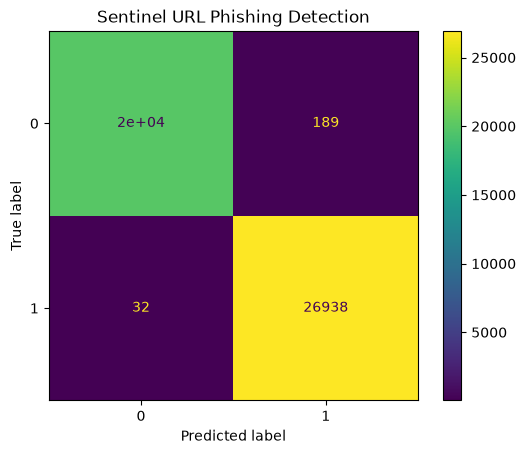

In [18]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title(
    "Sentinel URL Phishing Detection"
)

plt.show()

In [19]:
importance = pd.DataFrame({

    "Feature":
        X.columns,

    "Importance":
        model.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(
    importance
)

,Feature,Importance
13,IsHTTPS,0.425441
12,PathLength,0.236159
5,NoOfDigitsInURL,0.083147
0,URLLength,0.065172
4,NoOfLettersInURL,0.041097
11,NoOfDigitsInDomain,0.039315
9,NoOfOtherSpecialCharsInURL,0.022047
1,DomainLength,0.021863
3,NoOfSubDomain,0.021832
19,DotCount,0.016823


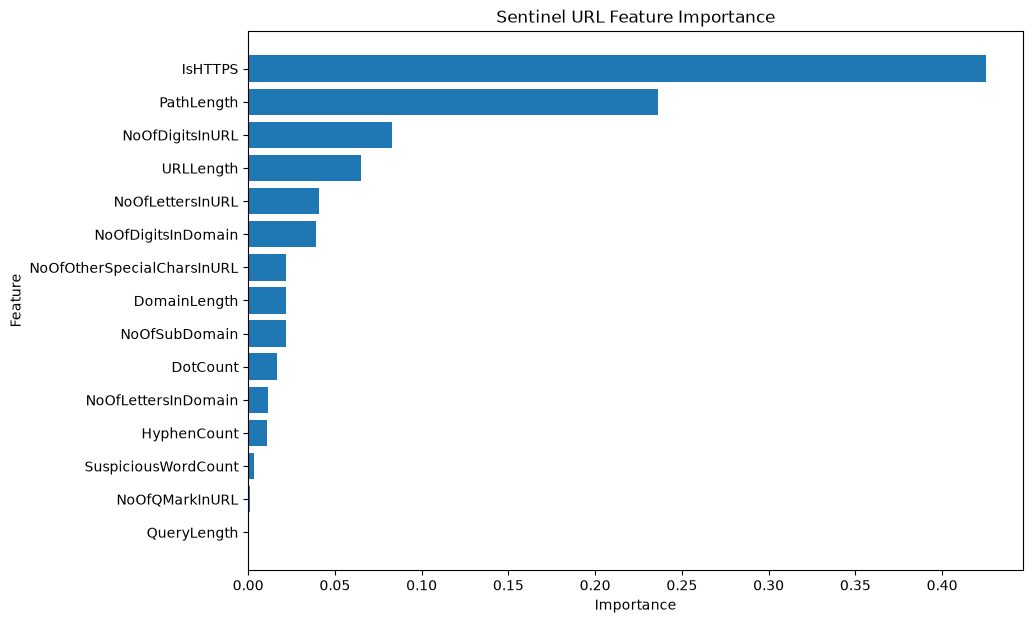

In [20]:
plt.figure(
    figsize=(10, 7)
)

top_features = (
    importance
    .head(15)
    .sort_values("Importance")
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Sentinel URL Feature Importance"
)

plt.show()

In [21]:
MODEL_DIR = (
    r"C:\Users\MALAY\sentinel"
    r"\ai\models\phishing"
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "url_model1.pkl"
)

FEATURES_PATH = os.path.join(
    MODEL_DIR,
    "url_features1.json"
)

joblib.dump(
    model,
    MODEL_PATH
)

with open(
    FEATURES_PATH,
    "w"
) as file:

    json.dump(
        list(X.columns),
        file,
        indent=4
    )

print(
    "Model saved at:"
)

print(
    MODEL_PATH
)

print(
    "\nFeatures saved at:"
)

print(
    FEATURES_PATH
)

Model saved at:
C:\Users\MALAY\sentinel\ai\models\phishing\url_model1.pkl

Features saved at:
C:\Users\MALAY\sentinel\ai\models\phishing\url_features1.json


In [22]:
def predict_url(url):

    features = extract_url_features(
        url
    )

    model_features = list(
        X.columns
    )

    input_data = pd.DataFrame(
        [[
            features.get(
                feature,
                0
            )
            for feature in model_features
        ]],
        columns=model_features
    )

    prediction = model.predict(
        input_data
    )[0]

    probabilities = model.predict_proba(
        input_data
    )[0]

    return {
        "prediction": prediction,
        "probabilities": probabilities,
        "features": features
    }

In [23]:
result = predict_url(
    "https://www.google.com"
)

print(result)

{'prediction': np.int64(1), 'probabilities': array([0.00329723, 0.99670277]), 'features': {'URLLength': 22, 'DomainLength': 14, 'IsDomainIP': 0, 'NoOfSubDomain': 1, 'NoOfLettersInURL': 17, 'NoOfDigitsInURL': 0, 'NoOfEqualsInURL': 0, 'NoOfQMarkInURL': 0, 'NoOfAmpersandInURL': 0, 'NoOfOtherSpecialCharsInURL': 1, 'NoOfLettersInDomain': 12, 'NoOfDigitsInDomain': 0, 'PathLength': 0, 'IsHTTPS': 1, 'HasPort': 0, 'IsShortenedURL': 0, 'SuspiciousWordCount': 0, 'HasAtSymbol': 0, 'HyphenCount': 0, 'DotCount': 2, 'QueryLength': 0, 'FragmentLength': 0}}


In [24]:
result = predict_url(
    "https://example.com/login"
)

print(result)

{'prediction': np.int64(0), 'probabilities': array([1., 0.]), 'features': {'URLLength': 25, 'DomainLength': 11, 'IsDomainIP': 0, 'NoOfSubDomain': 0, 'NoOfLettersInURL': 20, 'NoOfDigitsInURL': 0, 'NoOfEqualsInURL': 0, 'NoOfQMarkInURL': 0, 'NoOfAmpersandInURL': 0, 'NoOfOtherSpecialCharsInURL': 1, 'NoOfLettersInDomain': 10, 'NoOfDigitsInDomain': 0, 'PathLength': 6, 'IsHTTPS': 1, 'HasPort': 0, 'IsShortenedURL': 0, 'SuspiciousWordCount': 1, 'HasAtSymbol': 0, 'HyphenCount': 0, 'DotCount': 1, 'QueryLength': 0, 'FragmentLength': 0}}


In [25]:
def analyze_url(url):

    features = extract_url_features(
        url
    )

    model_features = list(
        X.columns
    )

    input_data = pd.DataFrame(
        [[
            features.get(
                feature,
                0
            )
            for feature in model_features
        ]],
        columns=model_features
    )

    prediction = model.predict(
        input_data
    )[0]

    probabilities = model.predict_proba(
        input_data
    )[0]

    classes = list(
        model.classes_
    )

    print("\n")
    print("=" * 60)
    print("             SENTINEL THREAT DETECTION")
    print("=" * 60)

    print("\nURL")
    print(url)

    print("\nFEATURES")
    print("-" * 60)

    for feature, value in features.items():

        print(
            f"{feature:35} : {value}"
        )

    print("\nMODEL")
    print("-" * 60)

    print(
        "Prediction:",
        prediction
    )

    print(
        "Classes:",
        classes
    )

    print(
        "Probabilities:",
        probabilities
    )

    return {
        "url": url,
        "prediction": int(prediction),
        "probabilities": probabilities.tolist(),
        "features": features
    }

In [26]:
result = analyze_url(
    "https://example.com/login"
)



             SENTINEL THREAT DETECTION

URL
https://example.com/login

FEATURES
------------------------------------------------------------
URLLength                           : 25
DomainLength                        : 11
IsDomainIP                          : 0
NoOfSubDomain                       : 0
NoOfLettersInURL                    : 20
NoOfDigitsInURL                     : 0
NoOfEqualsInURL                     : 0
NoOfQMarkInURL                      : 0
NoOfAmpersandInURL                  : 0
NoOfOtherSpecialCharsInURL          : 1
NoOfLettersInDomain                 : 10
NoOfDigitsInDomain                  : 0
PathLength                          : 6
IsHTTPS                             : 1
HasPort                             : 0
IsShortenedURL                      : 0
SuspiciousWordCount                 : 1
HasAtSymbol                         : 0
HyphenCount                         : 0
DotCount                            : 1
QueryLength                         : 0
FragmentLengt

In [31]:
def get_phishing_probability(
    model,
    input_data
):

    probabilities = (
        model.predict_proba(
            input_data
        )[0]
    )

    classes = list(
        model.classes_
    )

    if 1 in classes:

        index = classes.index(1)

        return probabilities[index]

    return 0.0

In [ ]:
phishing_probability = get_phishing_probability(
    model,
    input_data
)

risk_score = (
    phishing_probability * 100
)

print(
    f"Phishing Risk: {risk_score:.2f}%"
)

NameError: name 'input_data' is not defined

In [33]:
if risk_score >= 80:

    risk_level = "HIGH"

elif risk_score >= 50:

    risk_level = "MEDIUM"

else:

    risk_level = "LOW"

print(
    "Risk Level:",
    risk_level
)

NameError: name 'risk_score' is not defined